# Week 1 In-Class Exercise: Does Healthcare Spending Predict Life Expectancy?

In the textbook (Chapter 1), we explored whether **GDP per capita predicts life satisfaction**.

In this exercise, you'll explore a similar question with a different dataset:

> **Does healthcare spending per capita predict life expectancy across countries?**

You'll follow the same workflow:
1. Load and explore the data
2. Visualize the relationship
3. Fit a linear regression model
4. Try a k-Nearest Neighbors model
5. Compare and reflect

**Data source:** [World Bank](https://data.worldbank.org/) — Health expenditure per capita (current US$) and Life expectancy at birth.

### Useful API References

| Library | Documentation |
|---------|---------------|
| NumPy | [numpy.org/doc](https://numpy.org/doc/stable/reference/) |
| Pandas | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/) |
| Matplotlib | [matplotlib.org/stable/api](https://matplotlib.org/stable/api/index.html) |
| scikit-learn LinearRegression | [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) |
| scikit-learn KNeighborsRegressor | [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) |
| DataFrame.plot | [pandas.DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) |

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/pjmcswee/IST707-Notebooks/blob/main/week1/week1_inclass_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Step 1: Load the Data

We'll fetch the data directly from the World Bank API. The two indicators are:
- **SH.XPD.CHEX.PC.CD** — Current health expenditure per capita (US$)
- **SP.DYN.LE00.IN** — Life expectancy at birth (years)

This cell is provided for you — just run it.

In [26]:
import urllib.request
import json

def fetch_world_bank_indicator(indicator, date_range="2019:2022"):
    """Fetch most recent value per country from World Bank API."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}?date={date_range}&format=json&per_page=2000"
    with urllib.request.urlopen(url) as resp:
        data = json.loads(resp.read())
    
    # Get list of actual countries (not regional aggregates)
    url_c = "https://api.worldbank.org/v2/country?per_page=400&format=json"
    with urllib.request.urlopen(url_c) as resp:
        countries = json.loads(resp.read())
    country_codes = {c['id'] for c in countries[1] if c['region']['id'] != 'NA'}
    
    # Most recent non-null value per country
    result = {}
    for record in data[1]:
        code = record['countryiso3code']
        if (record['value'] is not None and 
            code in country_codes and 
            code not in result):
            result[code] = {
                'country': record['country']['value'],
                'value': record['value']
            }
    return result

print("Fetching healthcare spending data...")
health_data = fetch_world_bank_indicator('SH.XPD.CHEX.PC.CD')
print(f"  {len(health_data)} countries")

print("Fetching life expectancy data...")
life_data = fetch_world_bank_indicator('SP.DYN.LE00.IN')
print(f"  {len(life_data)} countries")

Fetching healthcare spending data...
  193 countries
Fetching life expectancy data...
  217 countries


## Step 2: Merge and Explore

This cell merges the two datasets into a single DataFrame. Run it and examine the output.

In [27]:
# Merge the two datasets
rows = []
for code in health_data:
    if code in life_data and health_data[code]['value'] > 0:
        rows.append({
            'Country': health_data[code]['country'],
            'Health Spending ($/capita)': round(health_data[code]['value'], 1),
            'Life Expectancy (years)': round(life_data[code]['value'], 2)
        })

df = pd.DataFrame(rows)
print(f"Combined dataset: {len(df)} countries\n")
df.describe()

Combined dataset: 193 countries



,Health Spending ($/capita),Life Expectancy (years)
count,193.000000,193.000000
mean,1361.101036,72.387513
std,2211.407569,8.047912
min,15.900000,18.820000
25%,96.700000,67.370000
50%,445.100000,73.250000
75%,1415.800000,77.580000
max,12586.200000,85.750000


## Step 3: Visualize the Relationship

Let's look at the raw scatter plot first:

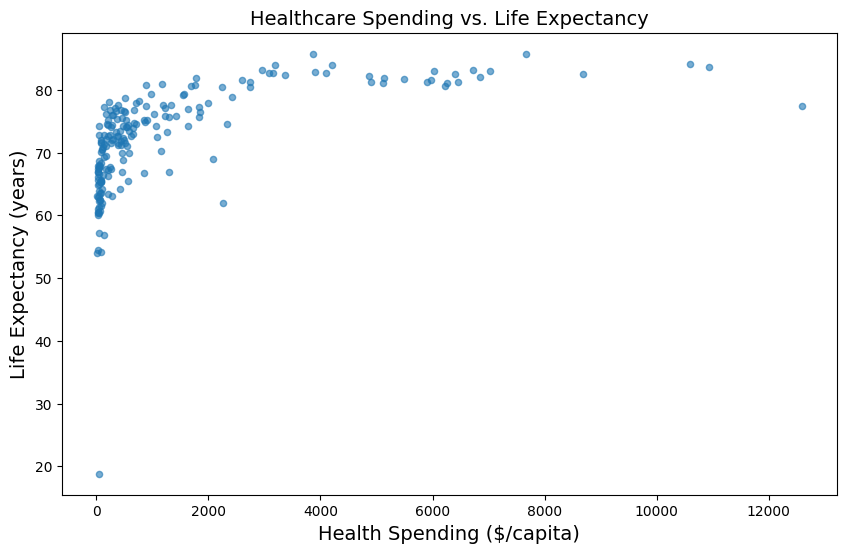

In [28]:
df.plot(kind='scatter', x='Health Spending ($/capita)', y='Life Expectancy (years)',
        figsize=(10, 6), alpha=0.6)
plt.title('Healthcare Spending vs. Life Expectancy')
plt.show()

### Observation

The relationship isn't perfectly linear — it shows **diminishing returns**. 
Countries that spend very little see big life expectancy gains from small spending increases, 
but wealthy countries get less "bang for their buck."

This is a classic **logarithmic** relationship. Let's apply a log transformation to the spending column:

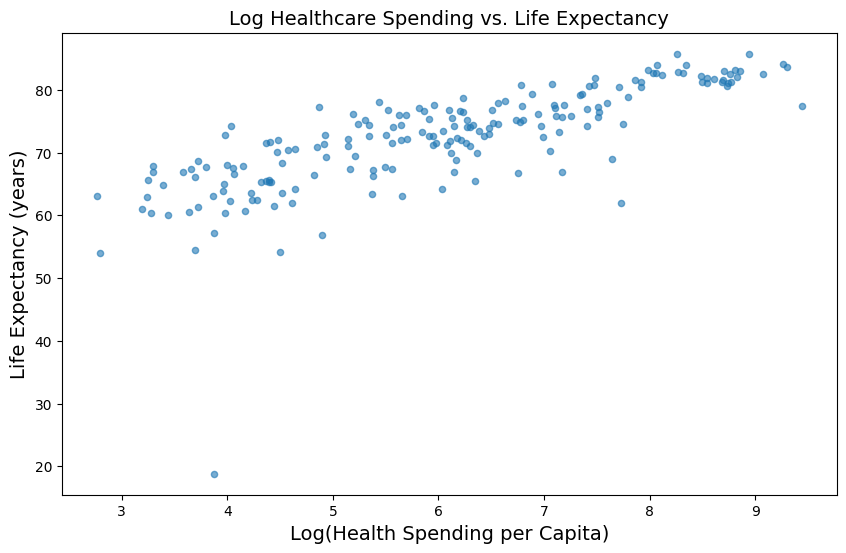

In [29]:
df['Log Health Spending'] = np.log(df['Health Spending ($/capita)'])

df.plot(kind='scatter', x='Log Health Spending', y='Life Expectancy (years)',
        figsize=(10, 6), alpha=0.6)
plt.xlabel('Log(Health Spending per Capita)')
plt.title('Log Healthcare Spending vs. Life Expectancy')
plt.show()

Much more linear! Transforming features to reveal simpler relationships is a key technique in ML.

We'll use `Log Health Spending` as our feature for modeling.

## Step 4: Fit a Linear Regression Model

**Your turn!** Using the pattern from the textbook notebook (`01_the_machine_learning_landscape.ipynb`), fit a `LinearRegression` model.

**Hint:** Look at how the textbook does it:
```python
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
```

API reference: [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [30]:
from sklearn.linear_model import LinearRegression

# Prepare the feature matrix X and target vector y
X = df[['Log Health Spending']].values
y = df['Life Expectancy (years)'].values

# TODO: Import LinearRegression and fit a model
# Your code here:

lr_model = LinearRegression()
lr_model.fit(X, y)


# TODO: Print the model's intercept, slope (coef_), and R² score
# Hint: model.intercept_, model.coef_[0], model.score(X, y)

print(f'Intercept: {lr_model.intercept_}')
print(f'Slope: {lr_model.coef_[0]}')
print(f'R-Squared: {lr_model.score(X,y)}')


Intercept: 49.791486103868365
Slope: 3.7452463669700986
R-Squared: 0.5861469235987309


**Question:** What does the slope mean in plain English? (Remember, the x-axis is *log* spending.)

*Hint:* Each unit increase in log(spending) corresponds to multiplying spending by *e* ≈ 2.72. A more intuitive way: each **doubling** of spending corresponds to a slope × ln(2) ≈ slope × 0.69 increase in life expectancy.

*Your answer:*
I think this means that for each increase in log(spending), life expecetancy increases by ~3.75


## Step 5: Visualize the Regression Line

**Your turn!** Plot the data points and overlay the linear regression line.

**Hint:** From the textbook:
```python
plt.scatter(X, y)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_range, model.predict(X_range), 'r-')
```

API reference: [matplotlib.pyplot.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) | [model.predict](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict)

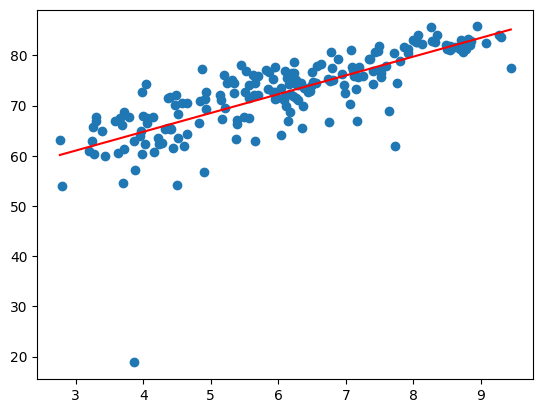

In [31]:
# TODO: Create a scatter plot of the data and overlay the regression line
# Your code here:

plt.scatter(X,y)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_range, lr_model.predict(X_range), 'r-')


## Step 6: Try k-Nearest Neighbors

**Your turn!** Fit a `KNeighborsRegressor` with k=5.

**Hint:** From the textbook:
```python
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(X, y)
```

API reference: [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

In [32]:
# TODO: Import KNeighborsRegressor, fit with n_neighbors=5, print R² score
# Your code here:
from sklearn.neighbors import KNeighborsRegressor

k_model = KNeighborsRegressor(n_neighbors=3)
k_model.fit(X,y)


print(f'R-Squared: {k_model.score(X,y)}')

R-Squared: 0.7142770959499609


## Step 7: Make a Prediction

A country spends **$2,000 per capita** on healthcare. What life expectancy does each model predict?

**Hint:** You need to log-transform the input before predicting:
```python
X_new = np.array([[np.log(2000)]])
model.predict(X_new)
```

In [33]:
# TODO: Predict life expectancy for a country spending $2,000/capita
# using both your linear regression model and your k-NN model.
# Your code here:

X_new = np.array([[np.log(2000)]])
k_model.predict(X_new)



array([74.41])

## Step 8: Compare the Models

**Your turn!** Create a single plot showing:
- The scatter points
- The linear regression line (in red)
- The k-NN predictions (in green, dashed)

**Hint:** Use `plt.plot()` twice — once for each model's predictions over `X_range`.

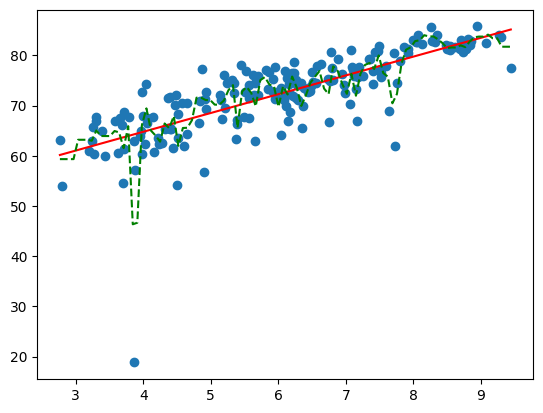

In [34]:
# TODO: Plot both models on the same figure
# Your code here:

plt.scatter(X,y)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_range, lr_model.predict(X_range), 'r-')
plt.plot(X_range, k_model.predict(X_range), 'g--')



## Reflection Questions

Answer each question in the cell below it (1-3 sentences each).

**Q1:** Why does the log transformation help? What real-world phenomenon does it capture?

*Your answer:*
The log transformation helps because it standardizes the data and helps to spread it out more which helps reveal more patterns. *This is my best guess I'm a bit rusty on logs*


**Q2:** Which model has a higher R² — and is that necessarily better? Think about overfitting vs. underfitting.

*Your answer:*
The K-Means model had a higher R-Squared score by about ~0.2. This is not necessarily better. This just means the K-Means model explains more of the variance in the data, however that could mean it is overfit. I cannot conclude for certain that it is overfit though without looking at more metrics.


**Q3:** The US spends ~$12,000/capita but has a life expectancy of ~77 years (lower than many countries spending far less). What might explain this? What does it tell us about the limits of a single-feature model?

*Your answer:* This tells us that the relationship between spending per capita and life expectancy may have a degrading affect after a certain amount of spending. Unfortunately, a single-feature model does not provide us any insights on why that may be the case. If we had more features we could analyze the relationships of additional features to see what contributes to life expecancy dropping in higher spending countries. 



**Q4:** What additional features would you add to improve predictions? Name at least two.

*Your answer:* More features I would consider adding to improve the model is percentage of population with access to healthcare, and maybe average income per capita to gain more insights on citizens economic status per country, potentially correlating to their access to healthcare.

